In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [279]:
# build the dataset
block_size = 5 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182441, 5]) torch.Size([182441])
torch.Size([22902, 5]) torch.Size([22902])
torch.Size([22803, 5]) torch.Size([22803])


# E01: Tune the hyperparameters of the training to beat my best validation loss of 2.2

In [297]:
# Tunables
iterations = 400000
# iterations = 200000
# iterations = 1000
neurons = 200
embeddings_per_character = 40

In [298]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, embeddings_per_character), generator=g)
W1 = torch.randn((embeddings_per_character * block_size, neurons), generator=g)
b1 = torch.randn(neurons, generator=g)
W2 = torch.randn((neurons, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [299]:
sum(p.nelement() for p in parameters)

46707

In [300]:
for p in parameters:
  p.requires_grad = True

In [301]:
lre = torch.linspace(-3, 0, iterations)
lrs = 10**lre

In [302]:
lri = []
lossi = []
stepi = []

In [303]:
for i in range(iterations):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, block_size, embeddings_per_character)
  h = torch.tanh(emb.view(-1, embeddings_per_character * block_size) @ W1 + b1) # (32, neurons)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  # lr = lrs[i]
  # lr = 10 ** -1.2
  # lr = 0.1
  # lr = 0.1 if i < 100000 else 0.01
  lr = 0.1 if i < 200000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())
  # lossi.append(loss.item())

print(loss.item())

2.169055461883545


In [ ]:
plt.plot(lri, lossi)

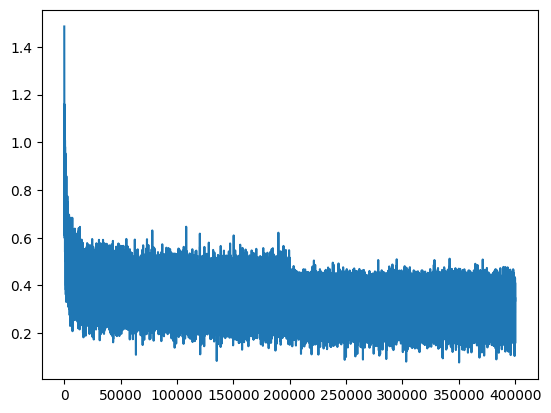

In [304]:
plt.plot(stepi, lossi)

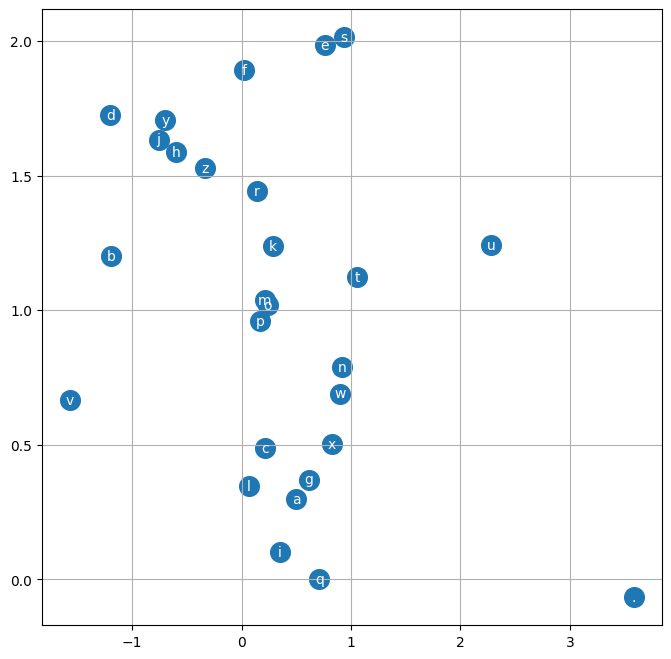

In [307]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

### Training set loss

In [305]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, embeddings_per_character * block_size) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0879, grad_fn=<NllLossBackward0>)

### Dev set loss

In [306]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, embeddings_per_character * block_size) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1937, grad_fn=<NllLossBackward0>)

### Sampling

In [311]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 5, 40])

In [313]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1, block_size, embeddings_per_character)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

careah.
amilik.
khiim.
siresty.
sacan.
kejrahien.
deliyah.
kaqeigon.
marah.
maiir.
kaleigh.
hamon.
caden.
juzs.
lilea.
jadia.
watthuus.
aryni.
jaceelinse.
meddeci.


# E02: I was not careful with the intialization of the network in this video. (1) What is the loss you'd get if the predicted probabilities at initialization were perfectly uniform? What loss do we achieve? (2) Can you tune the initialization to get a starting loss that is much more similar to (1)?

### Theoretical log loss (uniform distribution of probabilities)

In [315]:
import math
# (1) Baseline: perfectly uniform predictions over 27 classes
math.log(27)

3.295836866004329

### Tuning parameters so that we get something close to uniform distrbution

In [320]:
g = torch.Generator().manual_seed(2147483647)
init_scale = 0.01
C = init_scale * torch.randn((27, embeddings_per_character), generator=g)
W1 = init_scale * torch.randn((embeddings_per_character * block_size, neurons), generator=g)
b1 = init_scale * torch.randn(neurons, generator=g)
W2 = init_scale * torch.randn((neurons, 27), generator=g)
b2 = torch.zeros(27)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [321]:
def forward_loss(X, Y):
    emb = C[X]  # (N, block_size, embeddings_per_character)
    h = torch.tanh(emb.view(-1, embeddings_per_character * block_size) @ W1 + b1)
    logits = h @ W2 + b2
    return F.cross_entropy(logits, Y)

forward_loss(Xtr, Ytr)

tensor(3.2962, grad_fn=<NllLossBackward0>)

# E03: Read the Bengio et al 2003 paper (link above), implement and try any idea from the paper. Did it work?